# 1. Upload dataset

## 1.1 import thư viện

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1.2. Đọc file csv và mô tả dataset

In [16]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                 'PacktWorkshops/'\
                 'The-Data-Analysis-Workshop/master/'\
                 'Chapter07/Dataset/heart.csv')

df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [19]:
df.rename(index = str, \
          columns = {'cp' : 'chest_pain', \
                     'trestbps' : 'rest_bp', \
                     'fbs' : 'fast_bld_sugar', \
                     'restecg' : 'rest_ecg', \
                     'thalach' : 'max_hr', \
                     'exang' : 'ex_angina', \
                     'oldpeak' : 'st_depr', \
                     'ca' : 'colored_vessels', \
                     'thal' : 'thalassemia', }, inplace = True)


In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              303 non-null    int64  
 1   sex              303 non-null    int64  
 2   chest_pain       303 non-null    int64  
 3   rest_bp          303 non-null    int64  
 4   chol             303 non-null    int64  
 5   fast_bld_sugar   303 non-null    int64  
 6   rest_ecg         303 non-null    int64  
 7   max_hr           303 non-null    int64  
 8   ex_angina        303 non-null    int64  
 9   st_depr          303 non-null    float64
 10  slope            303 non-null    int64  
 11  colored_vessels  303 non-null    int64  
 12  thalassemia      303 non-null    int64  
 13  target           303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.5+ KB


# 2. Analysis các features với heart disease

## 2.1 Các đặc trưng có giá trị ngoại lai

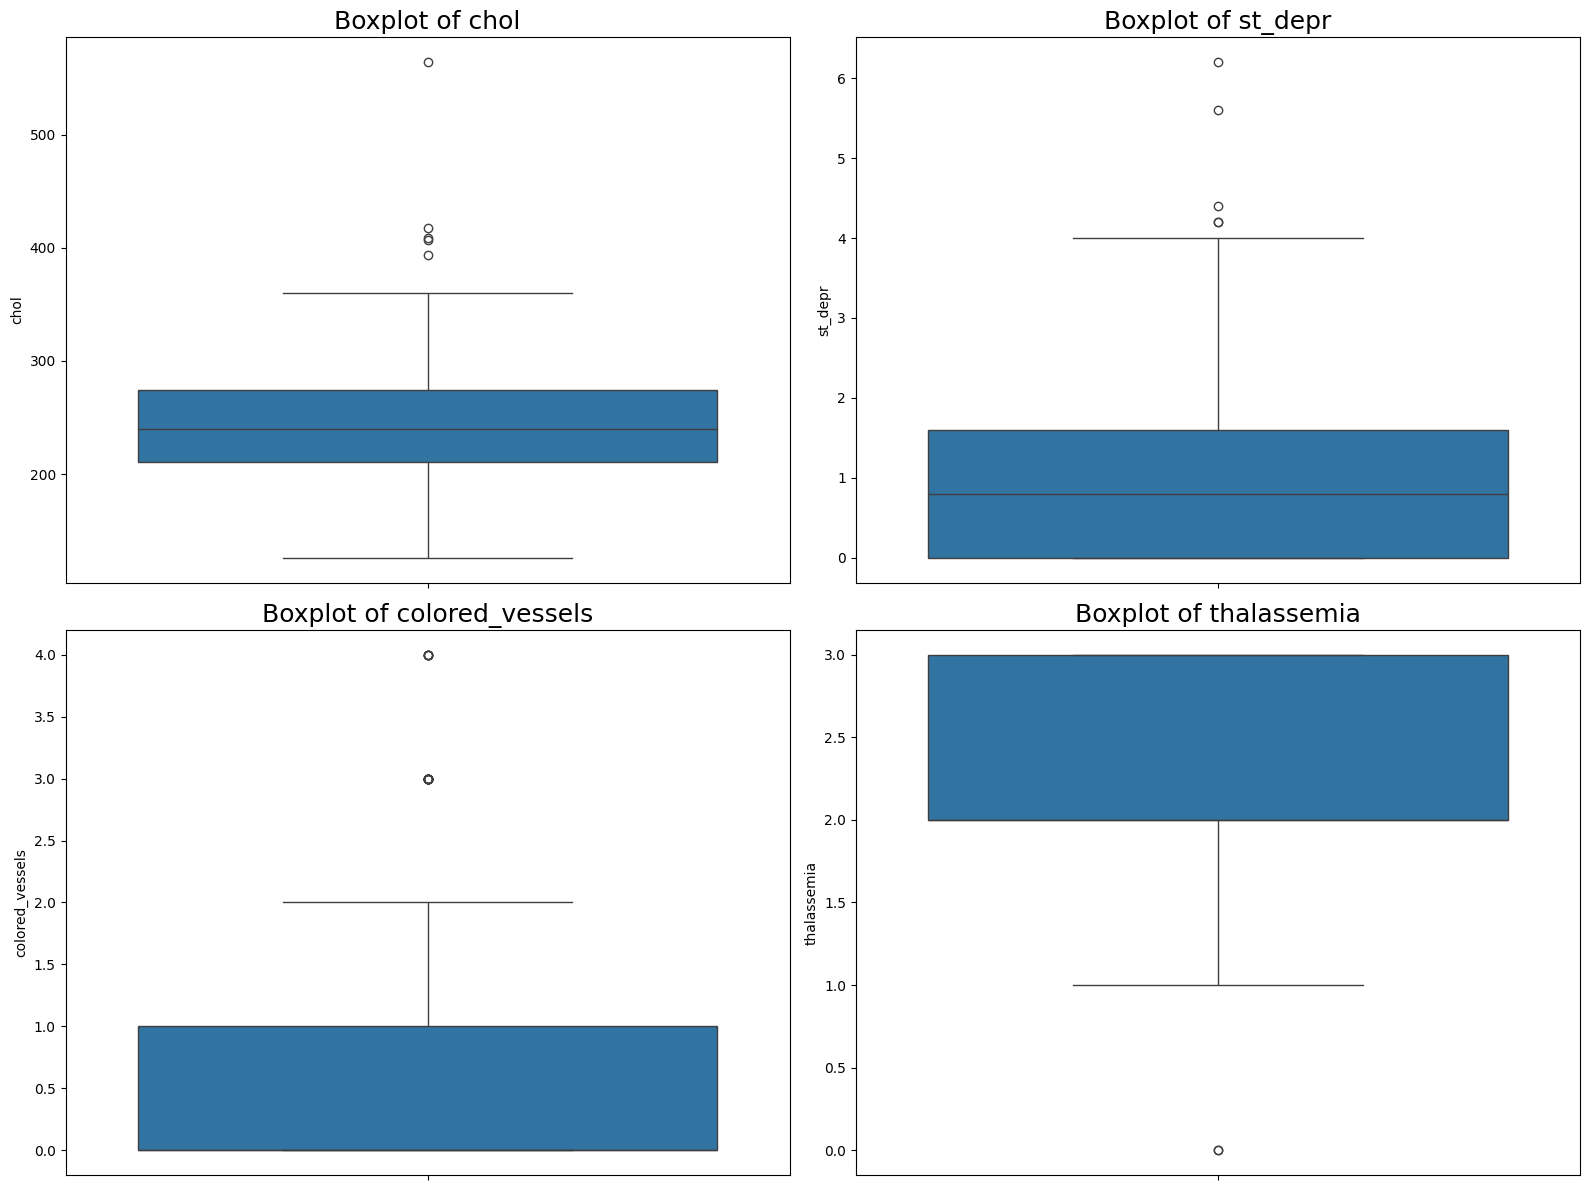

In [21]:
fts_outliers =  ['chol', 'st_depr', 'colored_vessels', 'thalassemia']

figs, axes = plt.subplots(2, 2, figsize = (16,12))

for i, col in enumerate(fts_outliers):
    sns.boxplot(df[col], ax = axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot of {col}', fontsize = 18)

# sns.set(palette = 'pastel', rc = {"figure.figsize": (12,8), \
#                                   "axes.titlesize" : 18, \
# "axes.labelsize" : 16, \
# "xtick.labelsize" : 16, \
# "ytick.labelsize" : 16 })

# chol = sns.boxplot(df['chol'])
plt.tight_layout()
plt.show()


## 2.2 Distribution của Age & Sex so với biến mục tiêu

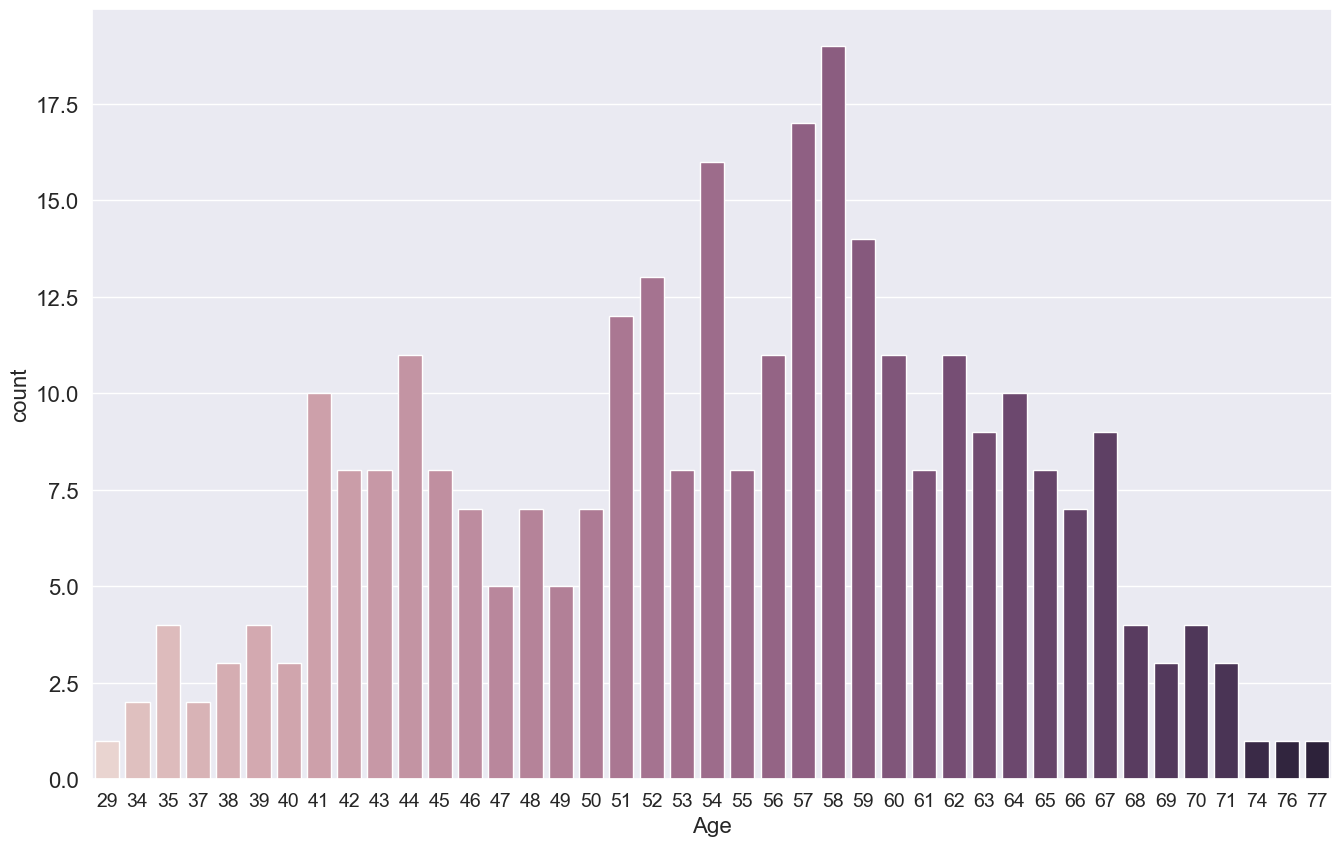

In [22]:
sns.set(palette = 'pastel', rc = {"figure.figsize": (16,10), \
                                  "axes.titlesize" : 18, \
"axes.labelsize" : 16, \
"xtick.labelsize" : 14, \
"ytick.labelsize" : 16 })


g = sns.countplot(x = 'age', data = df, hue = 'age', legend = False)
plt.xlabel('Age')

plt.show()

In [23]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

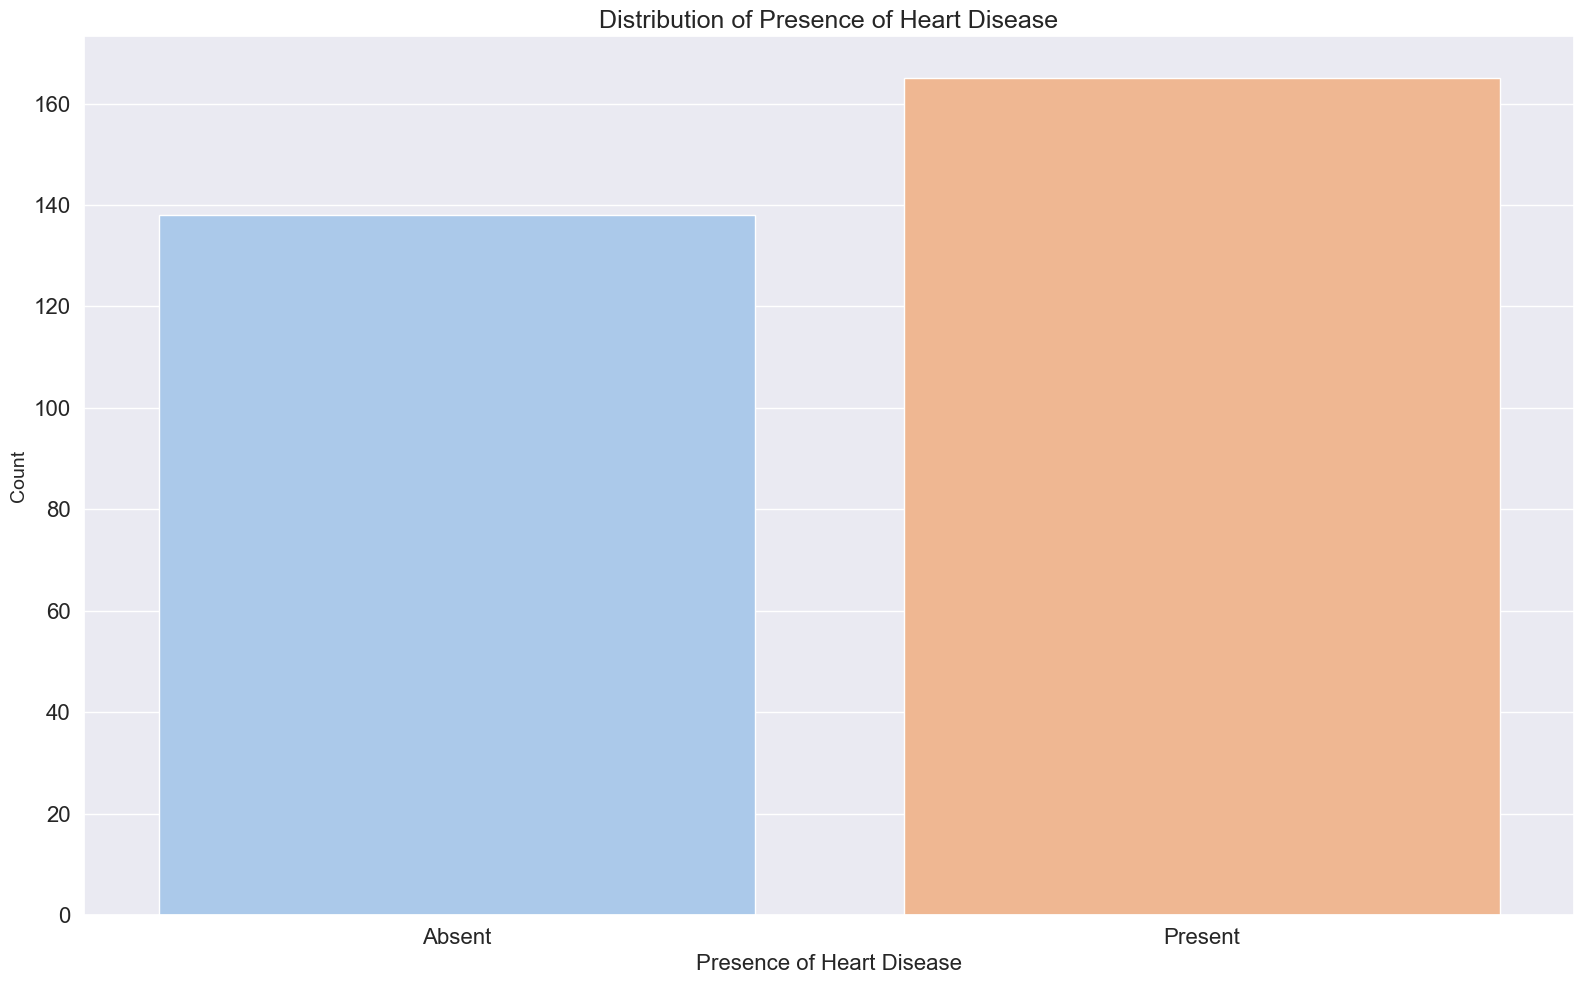

In [24]:
a = sns.countplot(x = 'target', data = df, hue= 'target', palette='pastel', legend = False)

a.set_title('Distribution of Presence of Heart Disease')
a.set_xticks([0, 1])
a.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.xlabel("Presence of Heart Disease", fontsize = 16)
plt.ylabel("Count", fontsize = 14)

plt.tight_layout()
plt.show()


In [25]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

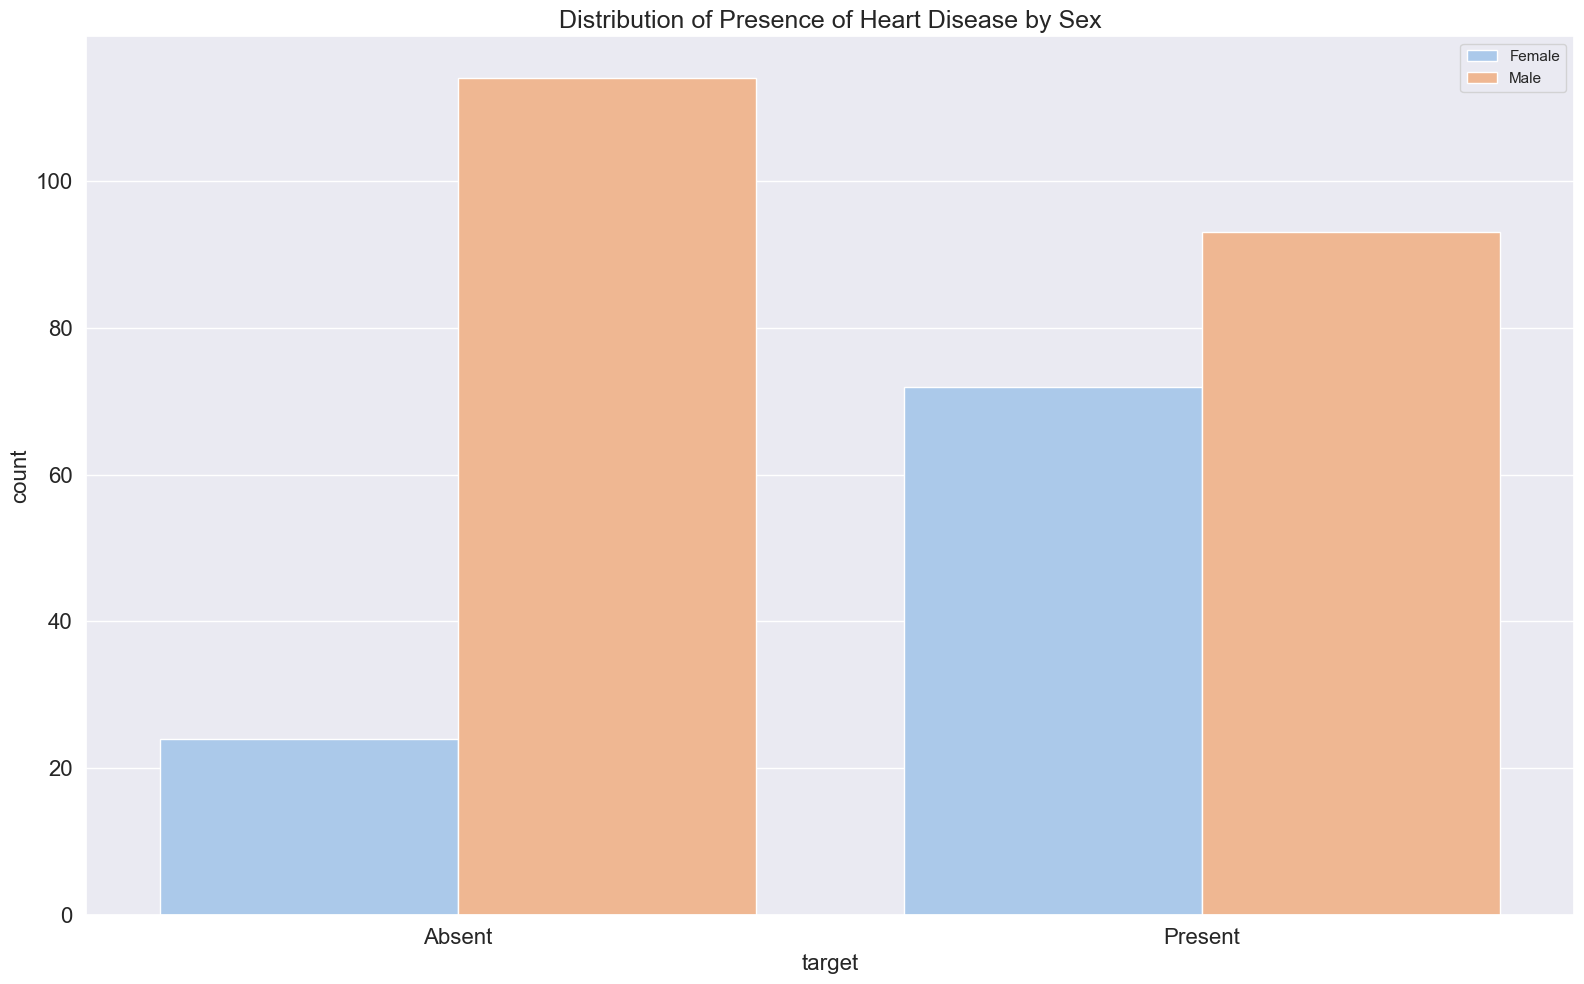

In [26]:
b = sns.countplot(x = 'target', data = df, hue = 'sex', palette='pastel', legend = False)

b.set_title('Distribution of Presence of Heart Disease by Sex')

b.set_xticks([0, 1])
b.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.legend(labels=['Female', 'Male'])
plt.tight_layout()
plt.show()


## 2.2 Relashionship giữa các đặc trưng và Biến Mục tiêu

In [27]:
df.chest_pain.value_counts()

chest_pain
0    143
2     87
1     50
3     23
Name: count, dtype: int64

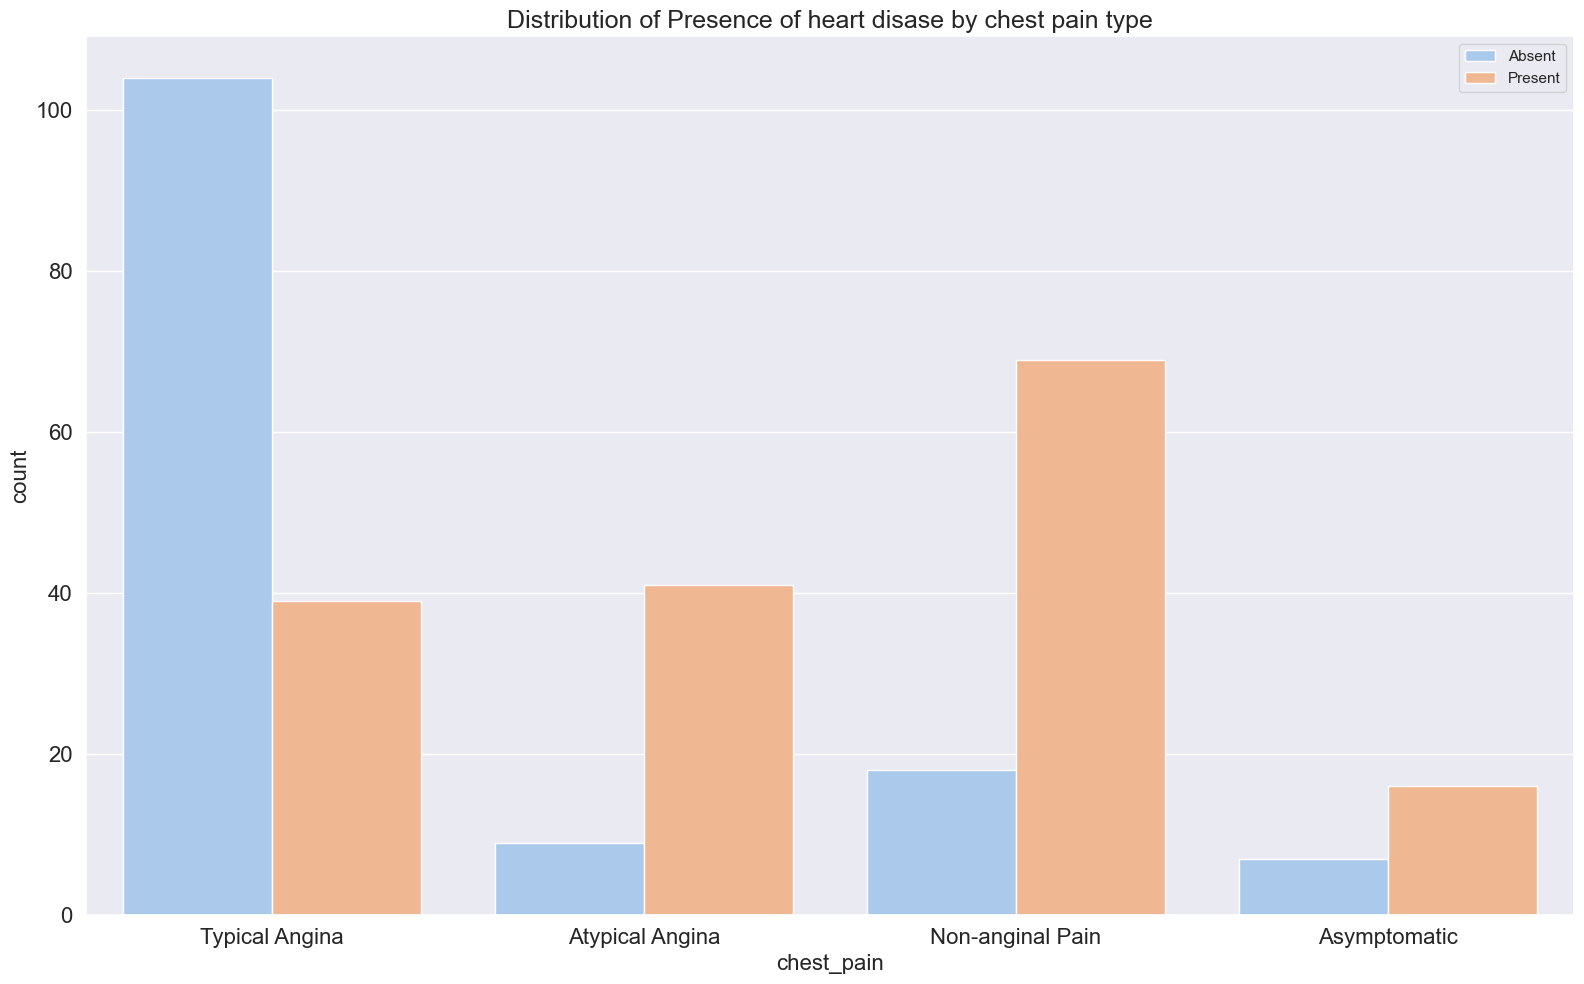

In [ ]:
c = sns.countplot(x = 'chest_pain', data = df, hue = 'target', palette='pastel', legend = False)

c.set_title('Distribution of Presence of heart disease by chest pain type')
c.set_xticks([0, 1, 2, 3])
c.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

In [29]:
df.colored_vessels.value_counts()

colored_vessels
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64

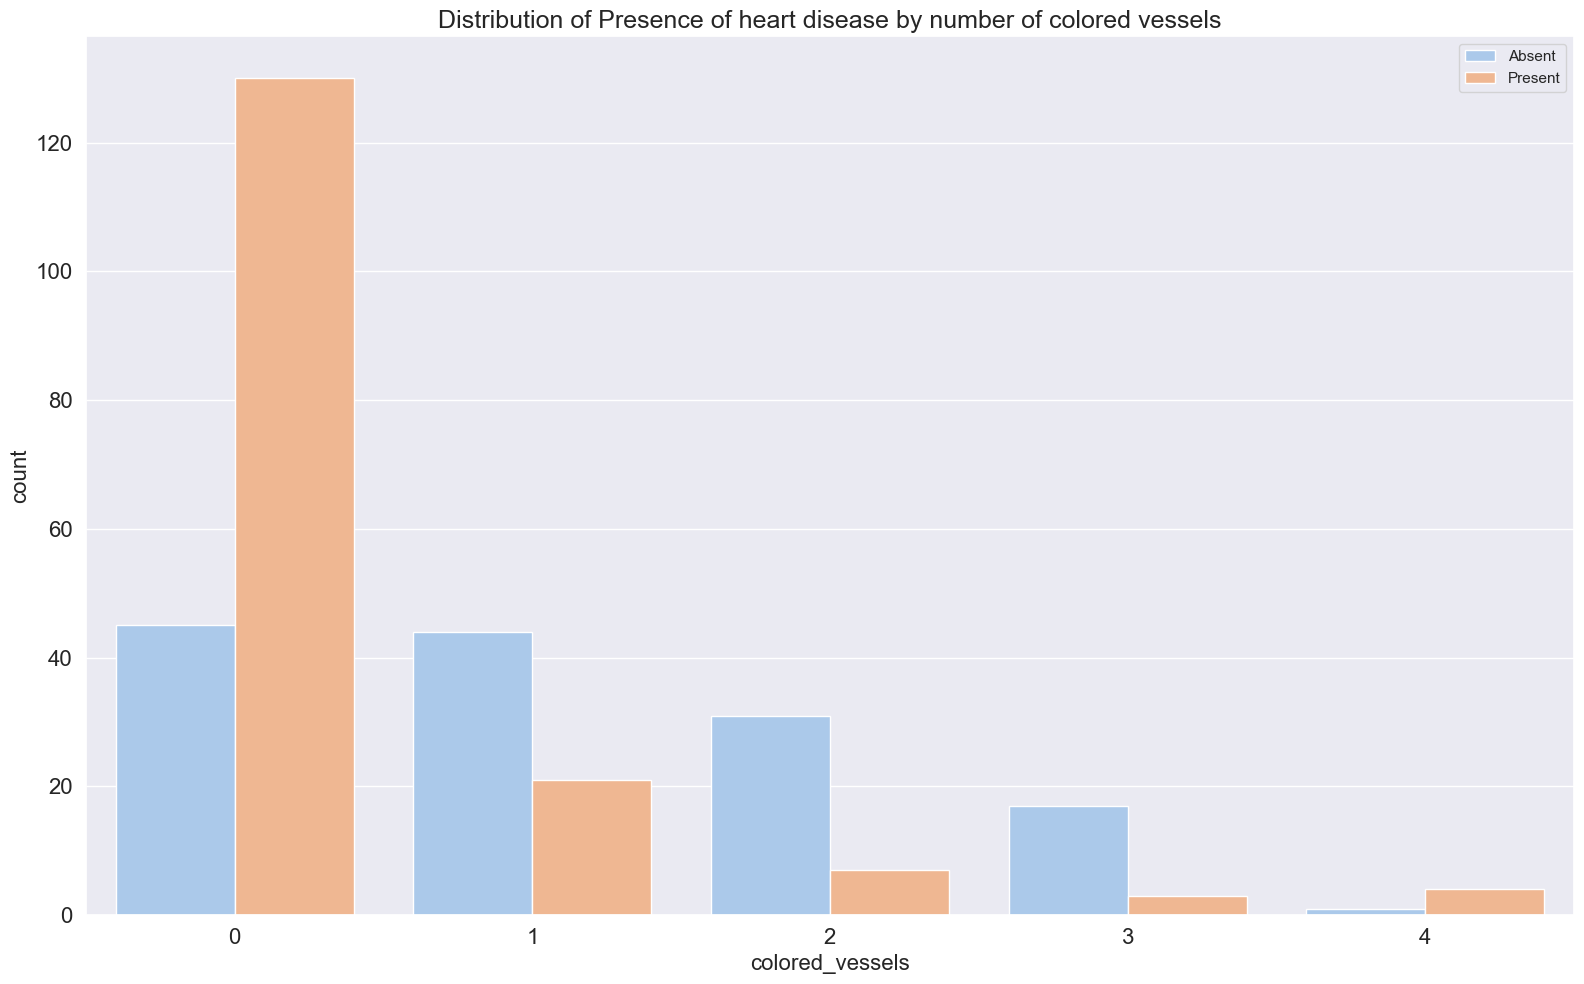

In [36]:
d = sns.countplot(x = 'colored_vessels', data= df, hue='target', palette='pastel', legend = False)
d.set_title('Distribution of Presence of heart disease by number of colored vessels')
d.set_xticks([0, 1, 2, 3, 4])
d.set_xticklabels(['0', '1', '2', '3', '4'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

In [30]:
df.slope.value_counts()

slope
2    142
1    140
0     21
Name: count, dtype: int64

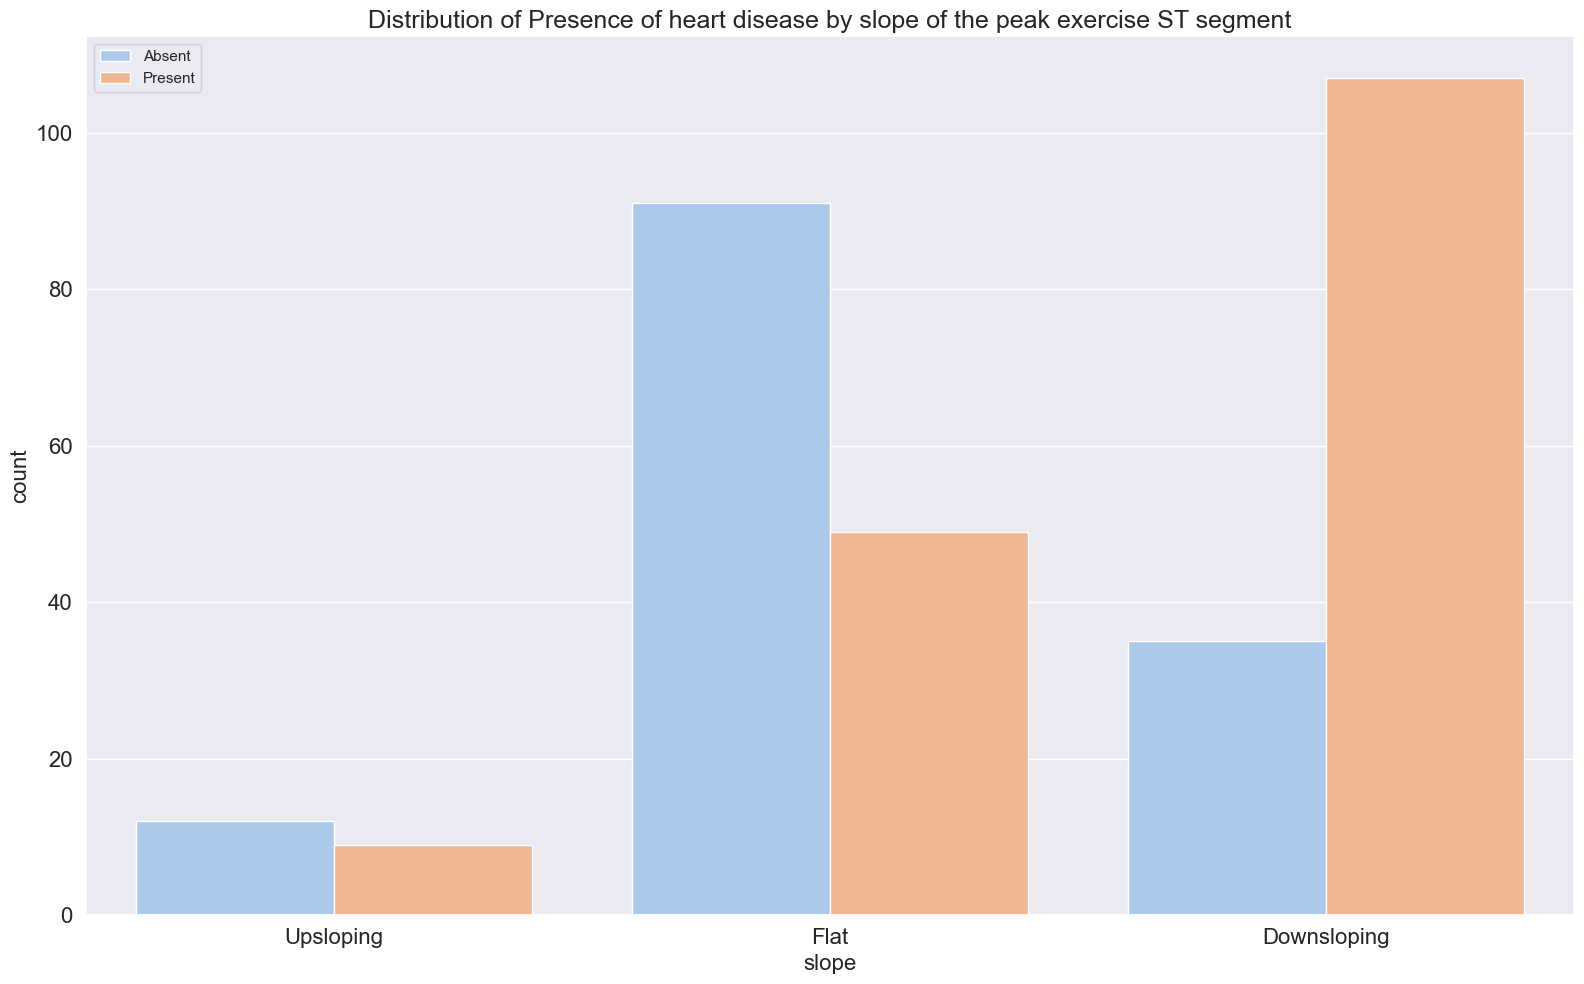

In [37]:
e = sns.countplot(x = 'slope', data = df, hue = 'target', palette='pastel', legend = False)
e.set_title('Distribution of Presence of heart disease by slope of the peak exercise ST segment')
e.set_xticks([0, 1, 2])
e.set_xticklabels(['Upsloping', 'Flat', 'Downsloping'], fontsize = 16)
plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()  
plt.show()

## 2.3 Relationship của bệnh tim và nhịp tim tối da

Text(0, 0.5, 'Maximum Heart Rate')

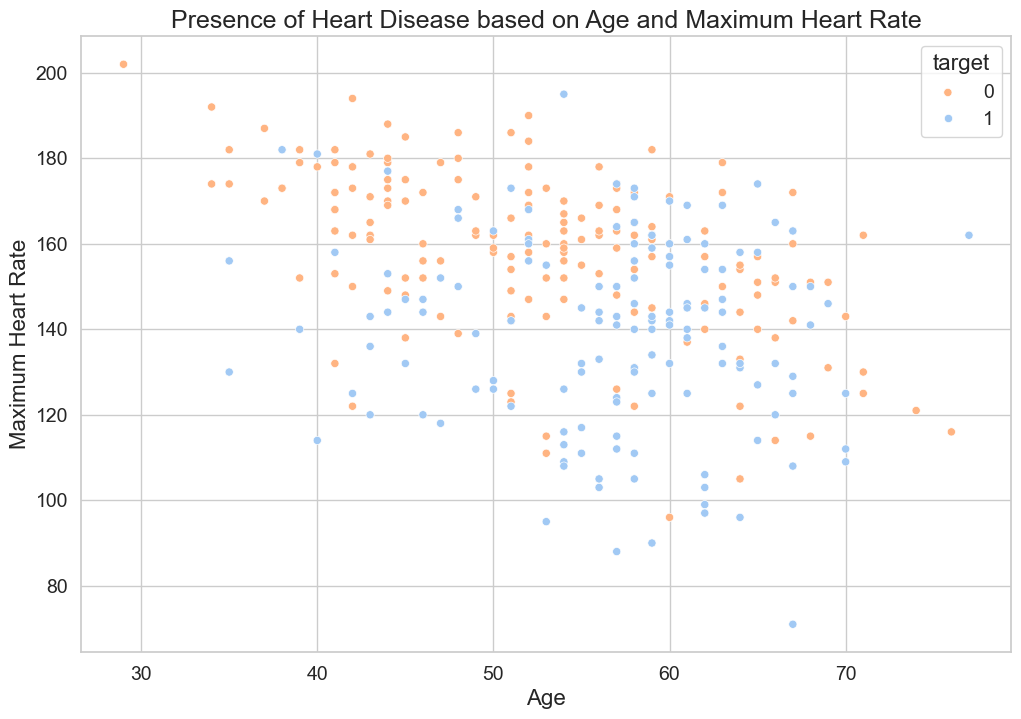

In [53]:
sns.set(style = 'whitegrid', palette = 'pastel', rc = {"figure.figsize": (12,8), "axes.titlesize" : 18, \
        "axes.labelsize" : 16, "xtick.labelsize" : 16, \
        "ytick.labelsize" : 16 }
)

f = sns.scatterplot(x = 'age', y ='max_hr', hue='target', data=df, palette= 'pastel', s=35)
f.set_title('Presence of Heart Disease based on Age and '\
            'Maximum Heart Rate')

f.legend(title='target', labels=["0", "1"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

Text(0, 0.5, 'Count')

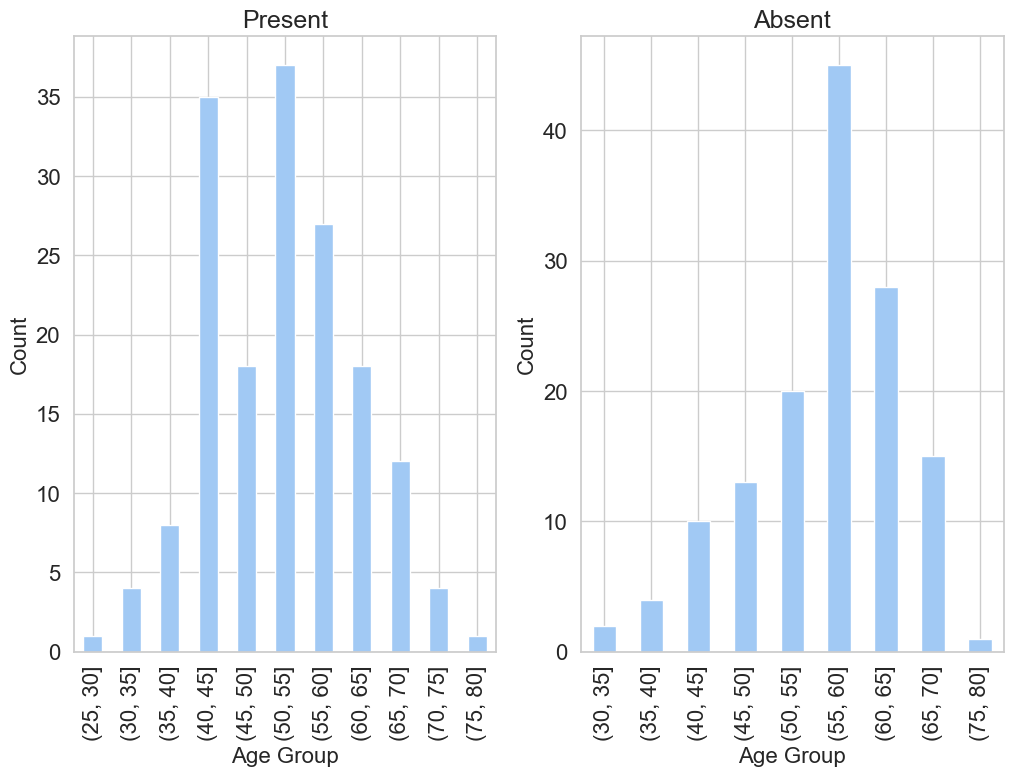

In [54]:

df['age_category'] = pd.cut(df.age, \
                            bins = list(np.arange(25, 85, 5)))

plt.subplot(121)
df[df.target == 1].groupby('age_category')['age']\
                    .count().plot(kind = 'bar')
                    
plt.title('Present')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('age_category')['age']\
.count().plot(kind = 'bar')

plt.title('Absent')
plt.xlabel('Age Group')
plt.ylabel('Count')



## 2.4 Ma trận tương quang heatmap

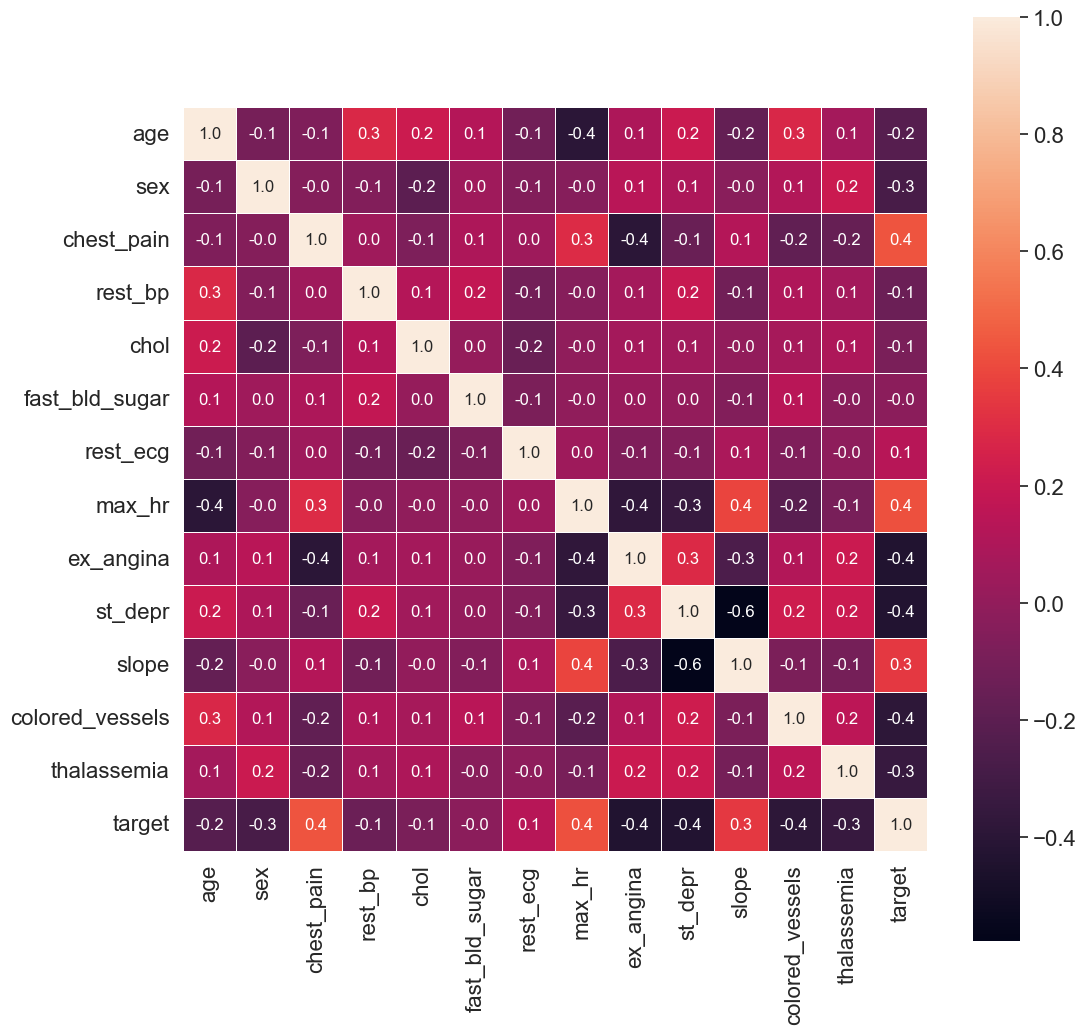

In [62]:
cols = [
    'age', 'sex', 'chest_pain', 'rest_bp', 'chol',
    'fast_bld_sugar', 'rest_ecg', 'max_hr',
    'ex_angina', 'st_depr', 'slope',
    'colored_vessels', 'thalassemia', 'target'
]

corr = df[cols].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".1f", linewidths=0.5, cmap="rocket", square=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()